# Inverted Pendulum Test of the Trajectory-Manifold Controller

This notebook is the step-by-step debugging version of
`scripts/run_inverted_pendulum_mc.py`.

The workflow is intentionally separated into:

1. normalized model and RK4 checks;
2. trajectory-data generation;
3. behavior-matrix construction;
4. encoder-decoder training and diagnostics;
5. one-step latent MPC;
6. decoded-plan consistency;
7. closed-loop manifold, LQR, and zero-input simulations;
8. solver diagnostics, saving, and plotting.

The controller and learned trajectories use normalized quantities:

\[
y =
[x/l,\ \dot{x}/\sqrt{lg},\ \theta,\ \dot{\theta}/\sqrt{g/l}],
\qquad
u = F/(mg).
\]

Therefore, `umax` is a normalized input bound and the associated physical-force
bound is `umax * m * g`.


## Imports and project path


In [1]:
from pathlib import Path
import importlib
import inspect
import math
import sys
import warnings
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch

# Run the notebook from either the repository root or a notebooks/ directory.
project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise RuntimeError(
        "Could not find the project src/ directory. "
        "Set project_root manually in this cell."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: c:\Users\bayer\PycharmProjects\koopman


In [26]:
import src.inverted_pendulum as inverted_pendulum
import src.manifold_control as manifold_control
import scripts.run_inverted_pendulum_mc as run_ip

# Reload while iterating on source files.
importlib.reload(inverted_pendulum)
importlib.reload(manifold_control)
importlib.reload(run_ip)

print("Run script:", inspect.getsourcefile(run_ip))
print("Model file:", inspect.getsourcefile(inverted_pendulum))
print("Manifold-control file:", inspect.getsourcefile(manifold_control))


Run script: c:\Users\bayer\PycharmProjects\koopman\scripts\run_inverted_pendulum_mc.py
Model file: c:\Users\bayer\PycharmProjects\koopman\src\inverted_pendulum.py
Manifold-control file: c:\Users\bayer\PycharmProjects\koopman\src\manifold_control.py


## Experiment configuration


In [8]:
# Use the compact profile while debugging individual stages.
# Set FAST_DEBUG=False to recover the current script defaults.
FAST_DEBUG = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 234
np.random.seed(seed)
torch.manual_seed(seed)

# Physical parameters
M = 2.0        # cart mass
m = 1.0        # pendulum mass
l = 1.0        # pendulum length
g = 9.81       # gravity

# Discrete control problem
H = 25
control_dt = 0.02                    # physical seconds
sim_duration = 1.0 if FAST_DEBUG else 5.0
num_steps = round(sim_duration / control_dt)
num_points = num_steps
x_dim = 4
u_dim = 1

# Normalized input bound: u = F / (m*g)
umax = 2.0 # 20

# Data generation
n_repeats = 15 if FAST_DEBUG else 100
sigma = 1.0
theta_max = math.pi / 20.0

# Autoencoder
alpha_dim = 4 + H
hidden_dims = (128, 128, 128)
epochs = 75 if FAST_DEBUG else 1000
training_max_iter = 1000
train_lr = 1e-3
batch_size = 256 if FAST_DEBUG else 512
lambda_alpha = 1e-5
test_fraction = 0.2
print_every = 10 if FAST_DEBUG else 250

checkpoint_name = (
    "behavior_decoder_inverse_pendulum_debug.pt"
    if FAST_DEBUG
    else "behavior_decoder_inverse_pendulum.pt"
)
checkpoint = project_root / "saves" / "saved_models" / checkpoint_name

# Latent MPC
control_lr = 5e-3
control_inner_max_iter = 100 if FAST_DEBUG else 300
control_outer_max_iter = 5
control_rho_x0 = 10.0
control_rho_growth = 10.0
control_rho_max = 1e7
control_constraint_tol = 2e-3
control_lambda_u_bounds = 1000.0
control_lambda_alpha = 1e-4
control_patience = 30
control_relative_loss_tol = 1e-6
control_multistart = 1 if FAST_DEBUG else 3
control_lbfgs_polish = False

results_path = (
    project_root / "saves" / "simulation_results" /
    "inverted_pendulum_notebook_results.npz"
)
plot_path = (
    project_root / "saves" / "figures" /
    "inverted_pendulum_notebook_results.png"
)

print("device:", device)
print("prediction horizon:", H * control_dt, "physical seconds")
print("simulation steps:", num_steps)
print("w_dim:", (H + 1) * x_dim + H * u_dim)
print("alpha_dim:", alpha_dim)
print("physical force bound:", umax * m * g)


device: cuda
prediction horizon: 0.5 physical seconds
simulation steps: 250
w_dim: 129
alpha_dim: 29
physical force bound: 19.62


## Normalization, references, and cost matrices


In [9]:
from src.inverted_pendulum import _physical_state_scale

t0, state_scale, mg = _physical_state_scale(m, g, l)
dt_norm = control_dt / t0
M_ratio = M / m

# y0 is entered in physical units for convenience.
y0_physical = np.array([0.0, 0.0, math.pi / 40.0, 0.0])
y0_normalized = y0_physical / state_scale

x_ref = np.zeros(x_dim)
u_ref = np.zeros(u_dim)

Q_np = np.diag([1.0, 1.0, 100.0, 10.0])
R_np = np.array([[0.1]])

Q = torch.tensor(Q_np, dtype=torch.float32, device=device)
R = torch.tensor(R_np, dtype=torch.float32, device=device)
x_ref_t = torch.tensor(x_ref, dtype=torch.float32, device=device)
u_ref_t = torch.tensor(u_ref, dtype=torch.float32, device=device)

w_dim = (H + 1) * x_dim + H * u_dim

print("natural time scale t0:", t0)
print("normalized RK4 step:", dt_norm)
print("state scale:", state_scale)
print("y0 physical:", y0_physical)
print("y0 normalized:", y0_normalized)


natural time scale t0: 0.3192754284070505
normalized RK4 step: 0.0626418390534633
state scale: [1.         3.13209195 1.         3.13209195]
y0 physical: [0.         0.         0.07853982 0.        ]
y0 normalized: [0.         0.         0.07853982 0.        ]


## Source-interface preflight


In [10]:
from src.inverted_pendulum import gen_max_theta_data, rk4_step

generation_signature = inspect.signature(gen_max_theta_data)
required_generation_arguments = {"umax", "control_dt", "seed"}
missing_generation_arguments = (
    required_generation_arguments - set(generation_signature.parameters)
)

print("gen_max_theta_data", generation_signature)
print("rk4_step", inspect.signature(rk4_step))

if missing_generation_arguments:
    raise RuntimeError(
        "The run script expects an updated gen_max_theta_data signature, but "
        f"the current source is missing: {sorted(missing_generation_arguments)}. "
        "Update src/inverted_pendulum.py before running the data-generation cells."
    )


gen_max_theta_data (M, m, g, l, sigma=0.5, theta_max=0.15, t_span=(0, 10), num_points=500, n_repeats=10, verbose=True, method='rk4', umax=2.0, control_dt=None, seed=None)
rk4_step (y, u, dt, M)


## RK4 smoke test


In [11]:
from scripts.run_inverted_pendulum_mc import (
    simulate_discrete_inverted_pendulum,
)

zero_u = lambda _k, _x: np.zeros(1)

t_test_norm, X_test, U_test = simulate_discrete_inverted_pendulum(
    zero_u,
    M_ratio=M_ratio,
    y0=y0_normalized,
    dt=dt_norm,
    num_steps=10,
    umax=umax,
)

assert X_test.shape == (4, 11)
assert U_test.shape == (1, 10)
assert t_test_norm.shape == (11,)
assert np.max(np.abs(U_test)) <= umax + 1e-12

print("RK4 test state shape:", X_test.shape)
print("RK4 test input shape:", U_test.shape)
print("initial state retained:", np.allclose(X_test[:, 0], y0_normalized))


RK4 test state shape: (4, 11)
RK4 test input shape: (1, 10)
initial state retained: True


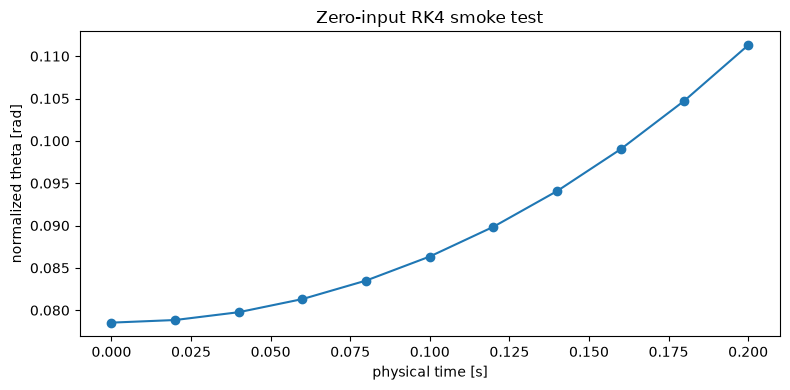

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(t_test_norm * t0, X_test[2], marker="o")
plt.xlabel("physical time [s]")
plt.ylabel("normalized theta [rad]")
plt.title("Zero-input RK4 smoke test")
plt.tight_layout()
plt.show()


# Generate inverted-pendulum trajectories


In [13]:
# This is the same normalized RK4 data-generation call used by the run script.
t_all, X_all, F_all = gen_max_theta_data(
    M,
    m,
    g,
    l,
    sigma=sigma,
    theta_max=theta_max,
    t_span=(0.0, sim_duration),
    num_points=num_points,
    n_repeats=n_repeats,
    umax=umax,
    control_dt=control_dt,
    seed=seed,
    method="rk4",
)

print("generated trajectories:", len(X_all))
print("state lengths:", [X.shape[1] for X in X_all[:5]])
print("input lengths:", [np.asarray(F).size for F in F_all[:5]])


Trajectory Generation: 100%|██████████| 100/100 [00:01<00:00, 57.93it/s]

generated trajectories: 100
state lengths: [251, 13, 3, 7, 19]
input lengths: [250, 12, 2, 6, 18]


## Data-shape and bound checks


In [14]:
for trajectory_index, (X, F) in enumerate(zip(X_all, F_all)):
    F = np.asarray(F, dtype=float).reshape(-1)
    assert X.shape[0] == 4
    assert X.shape[1] == F.size + 1, (
        trajectory_index, X.shape, F.shape
    )
    assert np.max(np.abs(F / mg)) <= umax + 1e-6

print("All trajectories have N+1 states and N held inputs.")
print("All generated normalized inputs satisfy the bound.")


All trajectories have N+1 states and N held inputs.
All generated normalized inputs satisfy the bound.


## Inspect generated trajectories


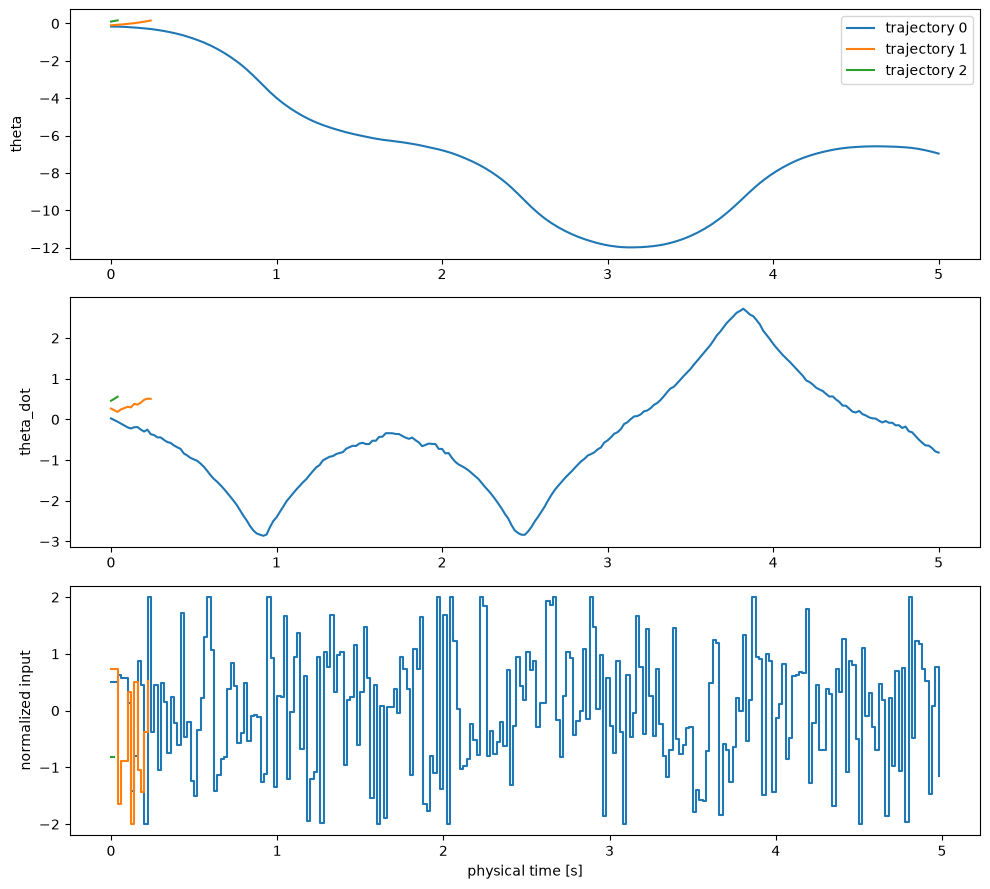

In [15]:
n_show = min(3, len(X_all))
figure, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False)

for i in range(n_show):
    X_norm = X_all[i] / state_scale[:, None]
    U_norm = np.asarray(F_all[i], dtype=float) / mg
    t_x = np.arange(X_norm.shape[1]) * control_dt
    t_u = np.arange(U_norm.size) * control_dt

    axes[0].plot(t_x, X_norm[2], label=f"trajectory {i}")
    axes[1].plot(t_x, X_norm[3], label=f"trajectory {i}")
    axes[2].step(t_u, U_norm, where="post", label=f"trajectory {i}")

axes[0].set_ylabel("theta")
axes[1].set_ylabel("theta_dot")
axes[2].set_ylabel("normalized input")
axes[2].set_xlabel("physical time [s]")
axes[0].legend()
figure.tight_layout()
plt.show()


# Build the behavior matrix


In [16]:
from src.manifold_control import build_trajectory_training_matrix

X_norm_all = [
    np.asarray(X, dtype=float) / state_scale.reshape(4, 1)
    for X in X_all
]
U_norm_all = [
    np.asarray(F, dtype=float).reshape(1, -1) / mg
    for F in F_all
]

W = build_trajectory_training_matrix(
    X_norm_all,
    U_norm_all,
    horizon=H,
    device=device,
    dtype=torch.float32,
)

assert W.shape[1] == w_dim
print("behavior matrix shape:", tuple(W.shape))


behavior matrix shape: (4323, 129)


## Train-test split and rank summary


In [17]:
from src.manifold_control import (
    behavior_matrix_rank_summary,
    split_behavior_matrix,
)

W_train, W_test = split_behavior_matrix(
    W,
    test_fraction=test_fraction,
    seed=seed,
)

summaries = {
    "W_all": behavior_matrix_rank_summary(W),
    "W_train": behavior_matrix_rank_summary(W_train),
    "W_test": behavior_matrix_rank_summary(W_test),
}

for name, summary in summaries.items():
    print(
        f"{name}: shape={summary['shape']}, "
        f"rank={summary['rank']}, "
        f"centered rank={summary['centered_rank']}, "
        f"leading singular values="
        f"{np.array2string(np.asarray(summary['leading_singular_values']), precision=3)}"
    )

print("Local deterministic manifold dimension n + Hm =", x_dim + H * u_dim)
print(
    "For a nonlinear manifold, the global numerical matrix rank does not "
    "need to equal the local manifold dimension."
)


W_all: shape=(4323, 129), rank=40, centered rank=40, leading singular values=[3399.377  656.112  407.401  158.079   70.77 ]
W_train: shape=(3458, 129), rank=44, centered rank=44, leading singular values=[3024.938  589.388  363.784  140.812   63.856]
W_test: shape=(865, 129), rank=61, centered rank=61, leading singular values=[1551.001  288.278  183.517   71.809   32.437]
Local deterministic manifold dimension n + Hm = 29
For a nonlinear manifold, the global numerical matrix rank does not need to equal the local manifold dimension.


# Train the behavior autoencoder


In [18]:
from src.manifold_control import train_decoder

autoencoder = train_decoder(
    W_train,
    x_dim=x_dim,
    u_dim=u_dim,
    horizon=H,
    alpha_dim=alpha_dim,
    hidden_dims=hidden_dims,
    epochs=epochs,
    max_iter=training_max_iter,
    lr=train_lr,
    print_every=print_every,
    checkpoint=checkpoint,
    device=device,
    batch_size=batch_size,
    lambda_alpha=lambda_alpha,
)

encoder = autoencoder.encoder
decoder = autoencoder.decoder
encoder.eval()
decoder.eval()

print("checkpoint:", checkpoint)


Training W=(3458, 129), method=minibatch, alpha_dim=29, device=cuda
epoch=0000, loss=21.262990, fit=21.262988
epoch=0250, loss=0.217447, fit=0.217443
epoch=0500, loss=0.182406, fit=0.182401
epoch=0750, loss=0.174238, fit=0.174233
saved autoencoder checkpoint to c:\Users\bayer\PycharmProjects\koopman\saves\saved_models\behavior_decoder_inverse_pendulum.pt
checkpoint: c:\Users\bayer\PycharmProjects\koopman\saves\saved_models\behavior_decoder_inverse_pendulum.pt


## Load an existing trained model instead


In [ ]:
# Run this cell instead of the training cell when reusing a checkpoint.
from src.manifold_control import load_autoencoder

autoencoder = load_autoencoder(
    checkpoint=checkpoint,
    alpha_dim=alpha_dim,
    w_dim=w_dim,
    hidden_dims=hidden_dims,
    device=device,
)

encoder = autoencoder.encoder
decoder = autoencoder.decoder
encoder.eval()
decoder.eval()


# Decoder diagnostics


In [19]:
from scripts.run_inverted_pendulum_mc import (
    _print_metrics,
    evaluate_inverted_pendulum_autoencoder,
)

train_metrics = evaluate_inverted_pendulum_autoencoder(
    encoder,
    decoder,
    W_train,
    horizon=H,
    dt=dt_norm,
    M_ratio=M_ratio,
)
test_metrics = evaluate_inverted_pendulum_autoencoder(
    encoder,
    decoder,
    W_test,
    horizon=H,
    dt=dt_norm,
    M_ratio=M_ratio,
)

_print_metrics("Train", train_metrics)
_print_metrics("Test", test_metrics)


Train reconstruction: aggregate NRMSE=0.0825726, trajectory median=0.133055, trajectory p95=0.703518, R^2=0.993026
  original data dynamics residual: mean=1.55322e-08, median=1.42263e-08, p95=3.25982e-08, max=5.41408e-08
  reconstructed dynamics residual: mean=0.0076013, median=0.00300692, p95=0.0301801, max=0.455828
Test reconstruction: aggregate NRMSE=0.0834198, trajectory median=0.130048, trajectory p95=0.684976, R^2=0.992926
  original data dynamics residual: mean=1.55884e-08, median=1.41549e-08, p95=3.27061e-08, max=5.41408e-08
  reconstructed dynamics residual: mean=0.00778329, median=0.00298894, p95=0.0292504, max=0.675529


## Inspect one reconstructed test trajectory


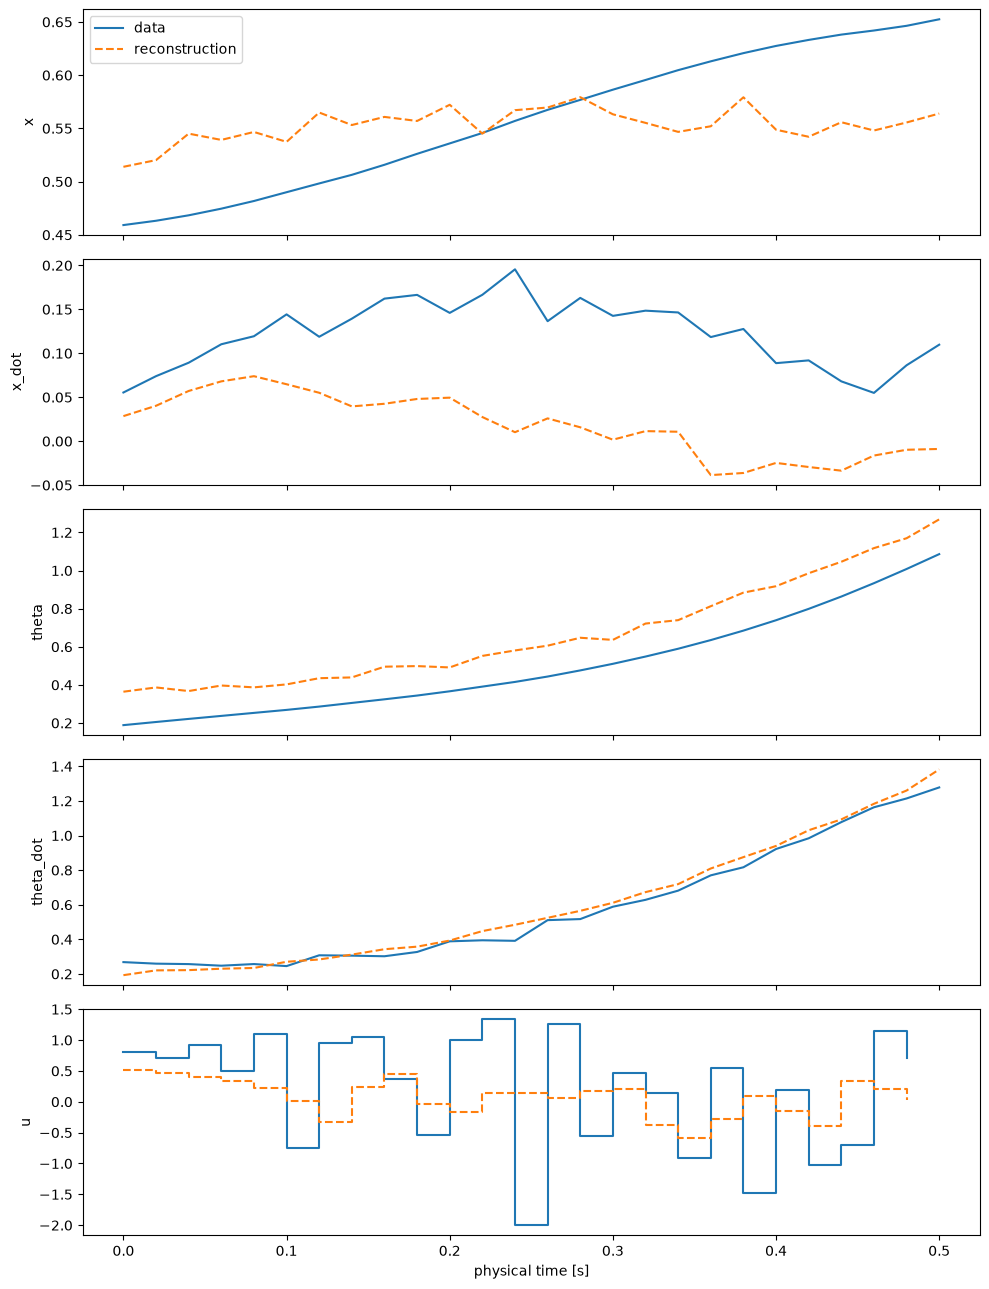

In [20]:
from src.manifold_control import unpack_w

test_index = 0

with torch.no_grad():
    w_true = W_test[test_index]
    alpha_test = encoder(w_true)
    w_reconstructed = decoder(alpha_test)

x_true, u_true = unpack_w(
    w_true,
    x_dim=x_dim,
    u_dim=u_dim,
    horizon=H,
)
x_reconstructed, u_reconstructed = unpack_w(
    w_reconstructed,
    x_dim=x_dim,
    u_dim=u_dim,
    horizon=H,
)

x_true = x_true.detach().cpu().numpy()
u_true = u_true.detach().cpu().numpy()
x_reconstructed = x_reconstructed.detach().cpu().numpy()
u_reconstructed = u_reconstructed.detach().cpu().numpy()

t_x = np.arange(H + 1) * control_dt
t_u = np.arange(H) * control_dt

figure, axes = plt.subplots(5, 1, figsize=(10, 13), sharex=True)
state_names = ["x", "x_dot", "theta", "theta_dot"]

for state_index, name in enumerate(state_names):
    axes[state_index].plot(t_x, x_true[:, state_index], label="data")
    axes[state_index].plot(
        t_x,
        x_reconstructed[:, state_index],
        linestyle="--",
        label="reconstruction",
    )
    axes[state_index].set_ylabel(name)

axes[4].step(t_u, u_true[:, 0], where="post", label="data")
axes[4].step(
    t_u,
    u_reconstructed[:, 0],
    where="post",
    linestyle="--",
    label="reconstruction",
)
axes[4].set_ylabel("u")
axes[4].set_xlabel("physical time [s]")
axes[0].legend()
figure.tight_layout()
plt.show()


# Solve one latent-MPC problem


In [21]:
from src.manifold_control import LatentBehaviorMPCSolver

single_step_solver = LatentBehaviorMPCSolver(
    decoder,
    x_dim,
    u_dim,
    H,
    Q,
    R,
    encoder=encoder,
    x_ref=x_ref_t,
    u_ref=u_ref_t,
    Q_terminal=5.0 * Q,
    u_bounds=(-umax, umax),
    lambda_u_bounds=control_lambda_u_bounds,
    lambda_alpha=control_lambda_alpha,
    rho_x0_init=control_rho_x0,
    rho_x0_growth=control_rho_growth,
    rho_x0_max=control_rho_max,
    constraint_tol=control_constraint_tol,
    max_outer_iter=control_outer_max_iter,
    inner_max_iter=control_inner_max_iter,
    lr=control_lr,
    patience=control_patience,
    relative_loss_tol=control_relative_loss_tol,
    use_lbfgs_polish=control_lbfgs_polish,
    device=device,
)

x_seed = x_ref_t.expand(H + 1, -1).clone()
x_seed[0] = torch.tensor(
    y0_normalized,
    dtype=torch.float32,
    device=device,
)
u_seed = u_ref_t.expand(H, -1).clone()

alpha_seed = single_step_solver.encode_initial_trajectory(x_seed, u_seed)
single_solution = single_step_solver.solve(
    x_seed[0],
    alpha_init=alpha_seed,
)

print("tracking objective:", single_solution.tracking_loss)
print("x0 RMSE:", single_solution.x0_rmse)
print("x0 NRMSE:", single_solution.x0_nrmse)
print("maximum input violation:", single_solution.max_input_violation)
print("inner iterations:", single_solution.iterations)
print("outer iterations:", single_solution.outer_iterations)
print("finite:", single_solution.finite)
print("feasible:", single_solution.feasible)
print("first normalized control:", single_solution.u[0].detach().cpu().numpy())


tracking objective: 9.86805534362793
x0 RMSE: 0.03640913963317871
x0 NRMSE: 0.07281827926635742
maximum input violation: 0.0
inner iterations: 1200
outer iterations: 4
finite: True
feasible: False
first normalized control: [-0.02959084]


## Compare the decoded plan with a true nonlinear rollout


mean plan-versus-rollout residual: 0.2892247
maximum plan-versus-rollout residual: 0.72558874


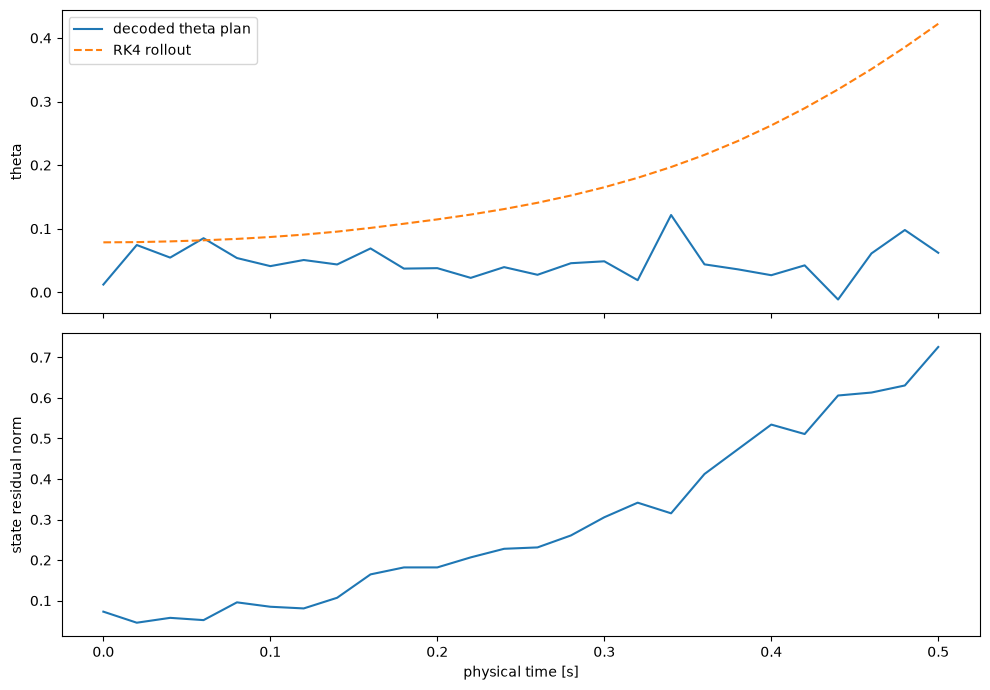

In [22]:
decoded_x_plan = single_solution.x.detach().cpu().numpy()
decoded_u_plan = single_solution.u.detach().cpu().numpy().reshape(-1)

true_rollout = np.zeros_like(decoded_x_plan)
true_rollout[0] = y0_normalized

for k, u_k in enumerate(decoded_u_plan):
    true_rollout[k + 1] = rk4_step(
        true_rollout[k],
        u_k,
        dt=dt_norm,
        M=M_ratio,
    )

plan_residual = np.linalg.norm(
    decoded_x_plan - true_rollout,
    axis=1,
)

print("mean plan-versus-rollout residual:", plan_residual.mean())
print("maximum plan-versus-rollout residual:", plan_residual.max())

figure, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t_x, decoded_x_plan[:, 2], label="decoded theta plan")
axes[0].plot(t_x, true_rollout[:, 2], linestyle="--", label="RK4 rollout")
axes[0].set_ylabel("theta")
axes[0].legend()

axes[1].plot(t_x, plan_residual)
axes[1].set_ylabel("state residual norm")
axes[1].set_xlabel("physical time [s]")
figure.tight_layout()
plt.show()


# Closed-loop control configuration


In [23]:
control_args = SimpleNamespace(
    M=M,
    m=m,
    l=l,
    g=g,
    H=H,
    alpha_dim=alpha_dim,
    umax=umax,
    device=str(device),
    seed=seed,
    control_lr=control_lr,
    control_inner_max_iter=control_inner_max_iter,
    control_outer_max_iter=control_outer_max_iter,
    control_rho_x0=control_rho_x0,
    control_rho_growth=control_rho_growth,
    control_rho_max=control_rho_max,
    control_constraint_tol=control_constraint_tol,
    control_lambda_u_bounds=control_lambda_u_bounds,
    control_lambda_alpha=control_lambda_alpha,
    control_patience=control_patience,
    control_relative_loss_tol=control_relative_loss_tol,
    control_multistart=control_multistart,
    control_lbfgs_polish=control_lbfgs_polish,
)


## Build the LQR fallback and manifold controller


In [24]:
from scripts.run_inverted_pendulum_mc import (
    _normalized_lqr_controller,
    make_inverted_pendulum_manifold_u_caller_args,
)

u_lqr = _normalized_lqr_controller(
    control_args,
    x_ref,
)

u_manifold = make_inverted_pendulum_manifold_u_caller_args(
    args=control_args,
    decoder=decoder,
    Q=Q,
    R=R,
    x_ref=x_ref_t,
    u_ref=u_ref_t,
    encoder=encoder,
    fallback_controller=u_lqr,
)

print("persistent solver:", u_manifold.solver)
print("initial warm-start state:", u_manifold.state)


persistent solver: <src.manifold_control.LatentBehaviorMPCSolver object at 0x00000236D969FA50>
initial warm-start state: {'previous_alpha': None, 'previous_x_plan': None, 'previous_u_plan': None, 'previous_feasible_u_plan': None}


## Run the manifold closed loop


In [28]:
import importlib
import scripts.run_inverted_pendulum_mc
importlib.reload(scripts.run_inverted_pendulum_mc)

<module 'scripts.run_inverted_pendulum_mc' from 'c:\\Users\\bayer\\PycharmProjects\\koopman\\scripts\\run_inverted_pendulum_mc.py'>

In [29]:
t_mani_norm, X_mani, U_mani = simulate_discrete_inverted_pendulum(
    u_manifold,
    M_ratio=M_ratio,
    y0=y0_normalized,
    dt=dt_norm,
    num_steps=num_steps,
    umax=umax,
)

assert X_mani.shape == (x_dim, num_steps + 1)
assert U_mani.shape == (u_dim, num_steps)
assert np.max(np.abs(U_mani)) <= umax + 1e-12

print("final manifold state:", X_mani[:, -1])
print(
    "final manifold state error:",
    np.linalg.norm(X_mani[:, -1] - x_ref),
)


final manifold state: [-0.50962652 -0.03208325  0.03624329  0.03501263]
final manifold state error: 0.5131159522488462


## Run LQR and zero-input baselines


In [30]:
t_lqr_norm, X_lqr, U_lqr = simulate_discrete_inverted_pendulum(
    u_lqr,
    M_ratio=M_ratio,
    y0=y0_normalized,
    dt=dt_norm,
    num_steps=num_steps,
    umax=umax,
)

t_zero_norm, X_zero, U_zero = simulate_discrete_inverted_pendulum(
    zero_u,
    M_ratio=M_ratio,
    y0=y0_normalized,
    dt=dt_norm,
    num_steps=num_steps,
    umax=umax,
)

print(
    "final normalized state errors:",
    {
        "manifold": np.linalg.norm(X_mani[:, -1] - x_ref),
        "lqr": np.linalg.norm(X_lqr[:, -1] - x_ref),
        "zero": np.linalg.norm(X_zero[:, -1] - x_ref),
    },
)


final normalized state errors: {'manifold': np.float64(0.5131159522488462), 'lqr': np.float64(0.0025134913918680476), 'zero': np.float64(1.0333673168869602)}


## Solver diagnostics


In [31]:
diagnostics = {
    key: np.asarray(value)
    for key, value in u_manifold.diagnostics.items()
}

print(
    "Feasible solves:",
    f"{100.0 * diagnostics['solver_feasible'].mean():.1f}%",
)
print(
    "Fallback fraction:",
    diagnostics["fallback_used"].mean(),
)
print(
    "Median/max x0 RMSE:",
    np.median(diagnostics["solver_x0_rmse"]),
    np.max(diagnostics["solver_x0_rmse"]),
)
print(
    "Median solver iterations:",
    np.median(diagnostics["solver_iterations"]),
)
print(
    "Maximum normalized input violation:",
    np.max(diagnostics["solver_max_input_violation"]),
)
print(
    "Maximum absolute normalized input:",
    max(
        np.max(np.abs(U_mani)),
        np.max(np.abs(U_lqr)),
        np.max(np.abs(U_zero)),
    ),
)
print(
    "Implied physical-force bound:",
    umax * m * g,
)


Feasible solves: 0.0%
Fallback fraction: 0.42292490118577075
Median/max x0 RMSE: 0.017605116590857506 0.09904002398252487
Median solver iterations: 1500.0
Maximum normalized input violation: 0.0255126953125
Maximum absolute normalized input: 2.0
Implied physical-force bound: 19.62


## Inspect diagnostics over closed-loop time


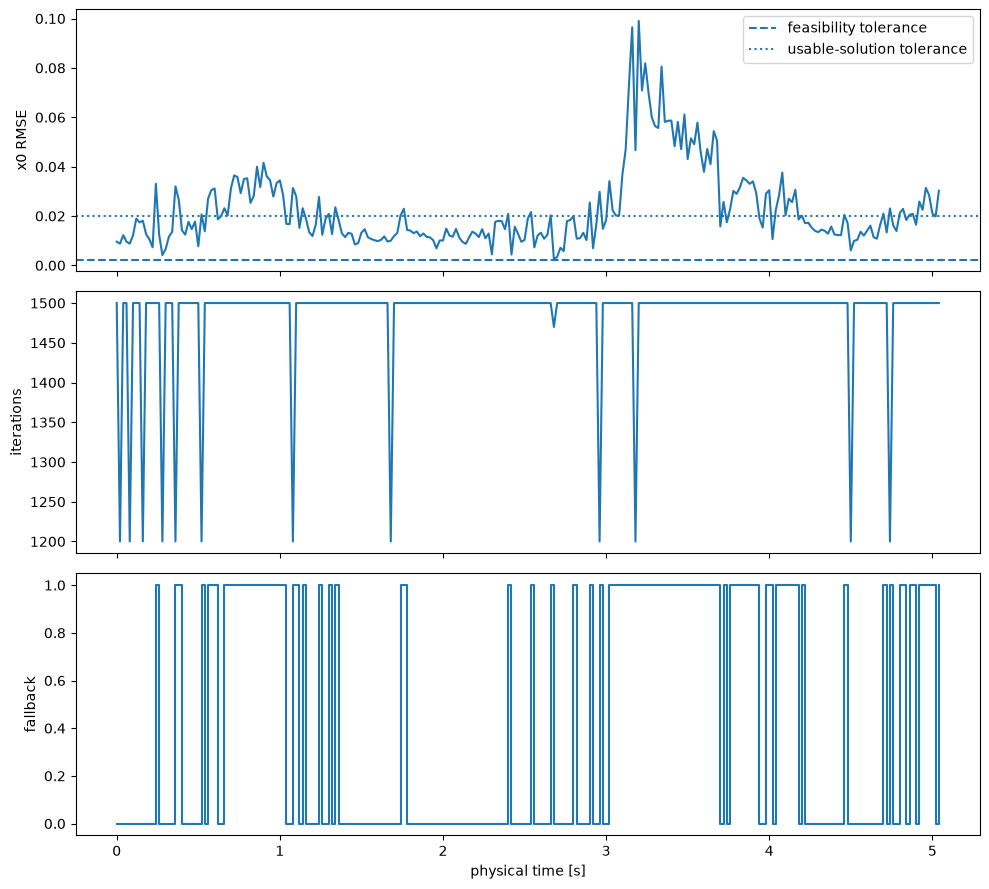

In [32]:
t_control_physical = np.arange(len(diagnostics["solver_x0_rmse"])) * control_dt

figure, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(t_control_physical, diagnostics["solver_x0_rmse"])
axes[0].axhline(
    control_constraint_tol,
    linestyle="--",
    label="feasibility tolerance",
)
axes[0].axhline(
    10.0 * control_constraint_tol,
    linestyle=":",
    label="usable-solution tolerance",
)
axes[0].set_ylabel("x0 RMSE")
axes[0].legend()

axes[1].plot(
    t_control_physical,
    diagnostics["solver_iterations"],
)
axes[1].set_ylabel("iterations")

axes[2].step(
    t_control_physical,
    diagnostics["fallback_used"].astype(int),
    where="post",
)
axes[2].set_ylabel("fallback")
axes[2].set_xlabel("physical time [s]")

figure.tight_layout()
plt.show()


## Closed-loop comparison plots


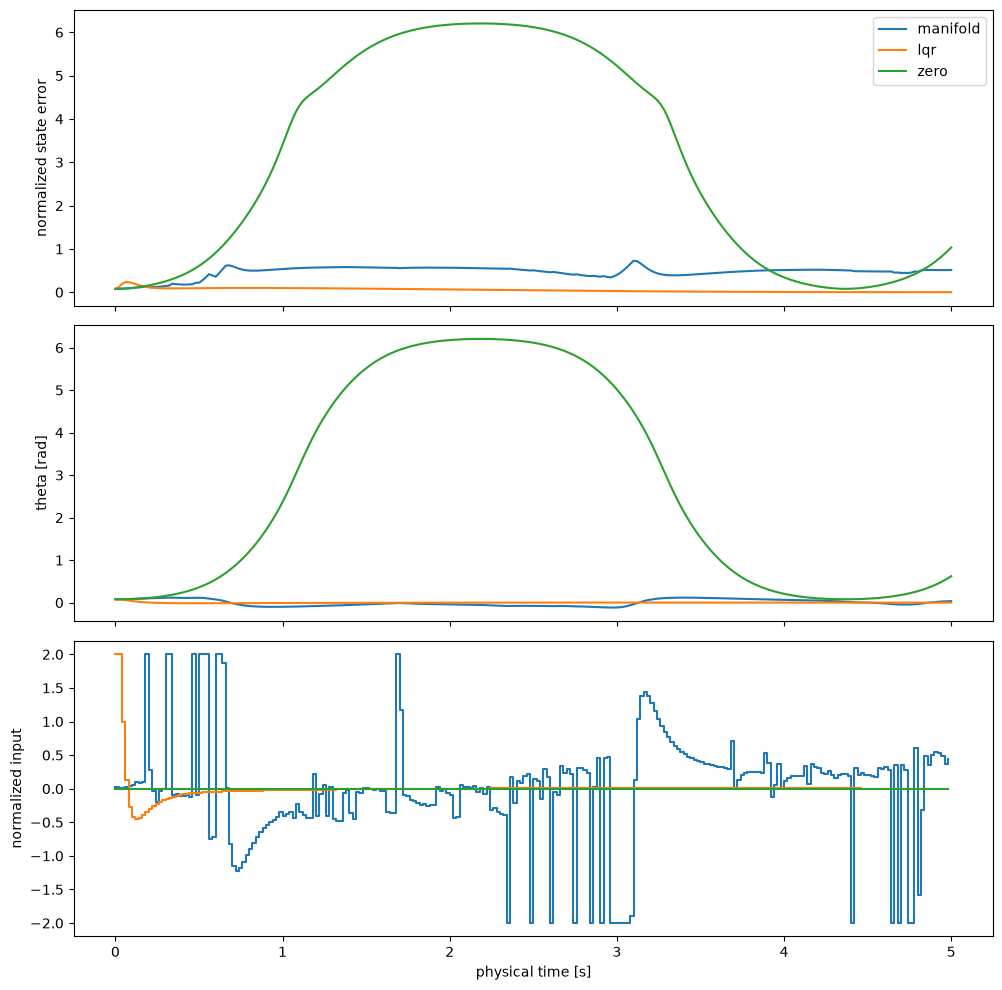

In [33]:
t_physical = t_mani_norm * t0

figure, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for name, X, U in (
    ("manifold", X_mani, U_mani),
    ("lqr", X_lqr, U_lqr),
    ("zero", X_zero, U_zero),
):
    axes[0].plot(
        t_physical,
        np.linalg.norm(X - x_ref[:, None], axis=0),
        label=name,
    )
    axes[1].plot(t_physical, X[2], label=name)
    axes[2].step(
        t_physical[:-1],
        U[0],
        where="post",
        label=name,
    )

axes[0].set_ylabel("normalized state error")
axes[1].set_ylabel("theta [rad]")
axes[2].set_ylabel("normalized input")
axes[2].set_xlabel("physical time [s]")
axes[0].legend()
figure.tight_layout()
plt.show()


## Convert results to physical units


In [34]:
X_mani_physical = X_mani * state_scale[:, None]
X_lqr_physical = X_lqr * state_scale[:, None]
X_zero_physical = X_zero * state_scale[:, None]

F_mani = U_mani * mg
F_lqr = U_lqr * mg
F_zero = U_zero * mg

print("maximum manifold force [N]:", np.max(np.abs(F_mani)))
print("maximum LQR force [N]:", np.max(np.abs(F_lqr)))


maximum manifold force [N]: 19.62
maximum LQR force [N]: 19.62


## Save results


In [35]:
results_path.parent.mkdir(parents=True, exist_ok=True)

np.savez(
    results_path,
    t_normalized=t_mani_norm,
    t_physical=t_physical,
    y0_normalized=y0_normalized,
    y0_physical=y0_physical,
    x_ref_normalized=x_ref,
    X_normalized_manifold=X_mani,
    U_normalized_manifold=U_mani,
    X_normalized_lqr=X_lqr,
    U_normalized_lqr=U_lqr,
    X_normalized_zero=X_zero,
    U_normalized_zero=U_zero,
    X_physical_manifold=X_mani_physical,
    F_physical_manifold=F_mani,
    X_physical_lqr=X_lqr_physical,
    F_physical_lqr=F_lqr,
    X_physical_zero=X_zero_physical,
    F_physical_zero=F_zero,
    **diagnostics,
)

print("saved:", results_path)


saved: c:\Users\bayer\PycharmProjects\koopman\saves\simulation_results\inverted_pendulum_notebook_results.npz


## Load results


In [ ]:
with np.load(results_path) as saved:
    print("saved keys:")
    print(saved.files)

    X_mani_loaded = saved["X_normalized_manifold"]
    U_mani_loaded = saved["U_normalized_manifold"]

print("loaded shapes:", X_mani_loaded.shape, U_mani_loaded.shape)


## Save the comparison figure


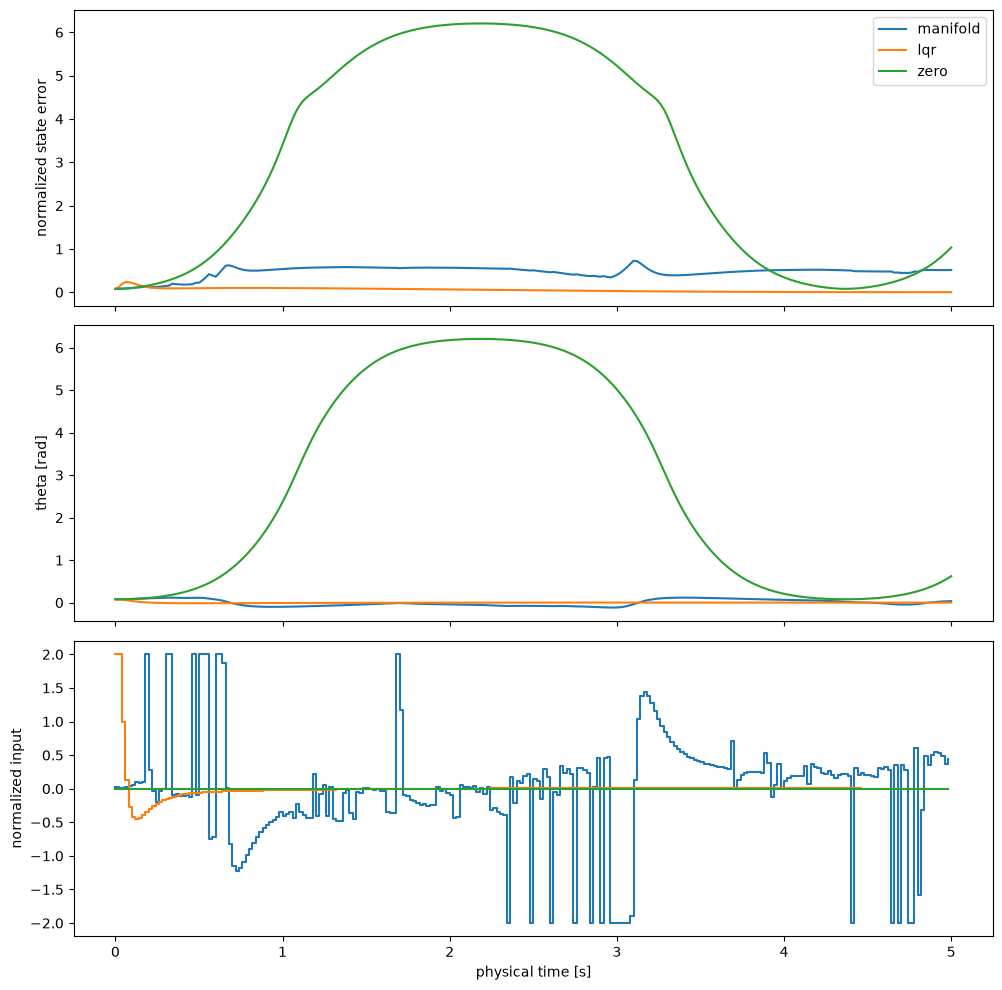

saved: c:\Users\bayer\PycharmProjects\koopman\saves\figures\inverted_pendulum_notebook_results.png


In [36]:
plot_path.parent.mkdir(parents=True, exist_ok=True)

figure, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
for name, X, U in (
    ("manifold", X_mani, U_mani),
    ("lqr", X_lqr, U_lqr),
    ("zero", X_zero, U_zero),
):
    axes[0].plot(
        t_physical,
        np.linalg.norm(X - x_ref[:, None], axis=0),
        label=name,
    )
    axes[1].plot(t_physical, X[2], label=name)
    axes[2].step(t_physical[:-1], U[0], where="post", label=name)

axes[0].set_ylabel("normalized state error")
axes[1].set_ylabel("theta [rad]")
axes[2].set_ylabel("normalized input")
axes[2].set_xlabel("physical time [s]")
axes[0].legend()
figure.tight_layout()
figure.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", plot_path)


## Optional physical animation


In [37]:
# This cell requires ffmpeg only when saving the animation.
from IPython.display import HTML
from src.plotting import animate_point_mass

# The animation helper expects force and state arrays of the same length.
F_animation = np.concatenate([F_mani.reshape(-1), F_mani.reshape(-1)[-1:]])

animation = animate_point_mass(
    t_physical,
    X_mani_physical[0],
    X_mani_physical[2],
    l,
    F_animation,
    case_name="Manifold Controller",
    frame_step=max(1, round(0.04 / control_dt)),
)

HTML(animation.to_jshtml())


## Reload source modules after edits


In [ ]:
importlib.reload(inverted_pendulum)
importlib.reload(manifold_control)
importlib.reload(run_ip)

print("Reloaded inverted-pendulum, manifold-control, and run-script modules.")
